#  Brain Tumor Detection — Model Evaluation

This notebook evaluates the trained ResNet50 model on the full test set.

We look beyond overall accuracy to understand:
- Which classes the model struggles with
- Where common confusions happen (e.g. glioma vs meningioma)
- Per-class precision, recall, and F1 score

## 1. Imports & Setup

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models

CLASSES     = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 224
BATCH_SIZE  = 32
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODELS_DIR  = Path('../models')
RESULTS_DIR = Path('../results')
DATA_DIR    = Path('../data')
RESULTS_DIR.mkdir(exist_ok=True)

print(f'Device: {DEVICE}')

Device: cuda


## 2. Load Model & Test Data

In [ ]:
class BrainTumorDataset(Dataset):
    def __init__(self, data_dir, split, transform=None):
        self.data_dir  = Path(data_dir) / split
        self.transform = transform
        self.samples   = []
        for label, cls in enumerate(CLASSES):
            class_path = self.data_dir / cls
            for img_name in os.listdir(class_path):
                self.samples.append((class_path / img_name, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = BrainTumorDataset(DATA_DIR, 'testing', test_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Test samples: {len(test_dataset)}')

# Load model
model = models.resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(256, NUM_CLASSES)
)
model.load_state_dict(torch.load(MODELS_DIR / 'best_model.pth', map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print(' Model loaded successfully!')

Test samples: 1600
✅ Model loaded successfully!


## 3. Run Inference on Full Test Set

In [ ]:
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        preds   = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

accuracy = (all_preds == all_labels).mean()
print(f'Overall Test Accuracy: {accuracy:.4f} ({accuracy:.2%})')

Overall Test Accuracy: 0.9444 (94.44%)


## 4. Classification Report

Per-class breakdown of precision, recall, and F1 score.

- **Precision** — of all predicted positives, how many were correct?
- **Recall** — of all actual positives, how many did the model catch? (critical for medical AI)
- **F1** — harmonic mean of precision and recall

In [ ]:
print('Classification Report')
print('=' * 60)
print(classification_report(all_labels, all_preds, target_names=CLASSES))

Classification Report
              precision    recall  f1-score   support

      glioma       0.99      0.81      0.89       400
  meningioma       0.89      0.98      0.93       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



## 5. Confusion Matrix

Each row is the actual class, each column is the predicted class.
Off-diagonal values are misclassifications — the higher the diagonal, the better.

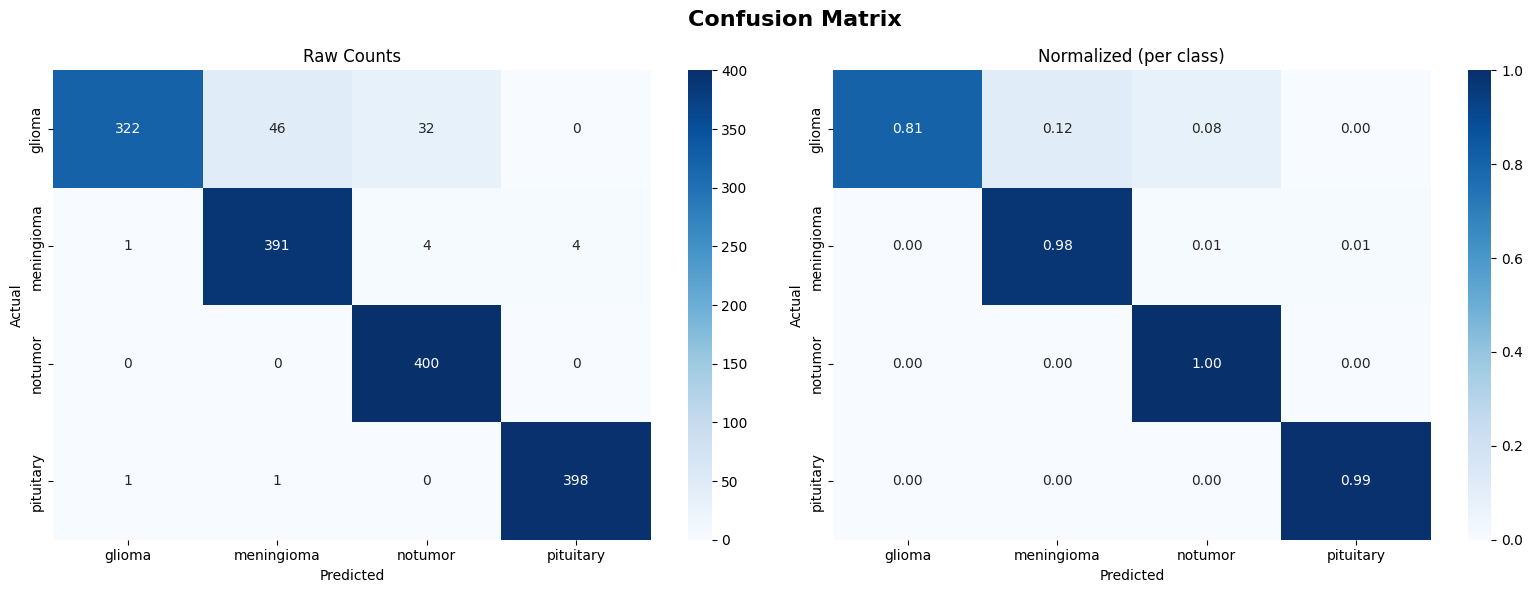

✅ Saved → results/confusion_matrix.png


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix', fontsize=16, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Raw Counts')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Normalized (row-wise)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title('Normalized (per class)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved → results/confusion_matrix.png')

## 6. ROC Curves (One-vs-Rest)

ROC curves show the tradeoff between true positive rate and false positive rate at different thresholds.
AUC (Area Under Curve) close to 1.0 means the model is a strong classifier for that class.

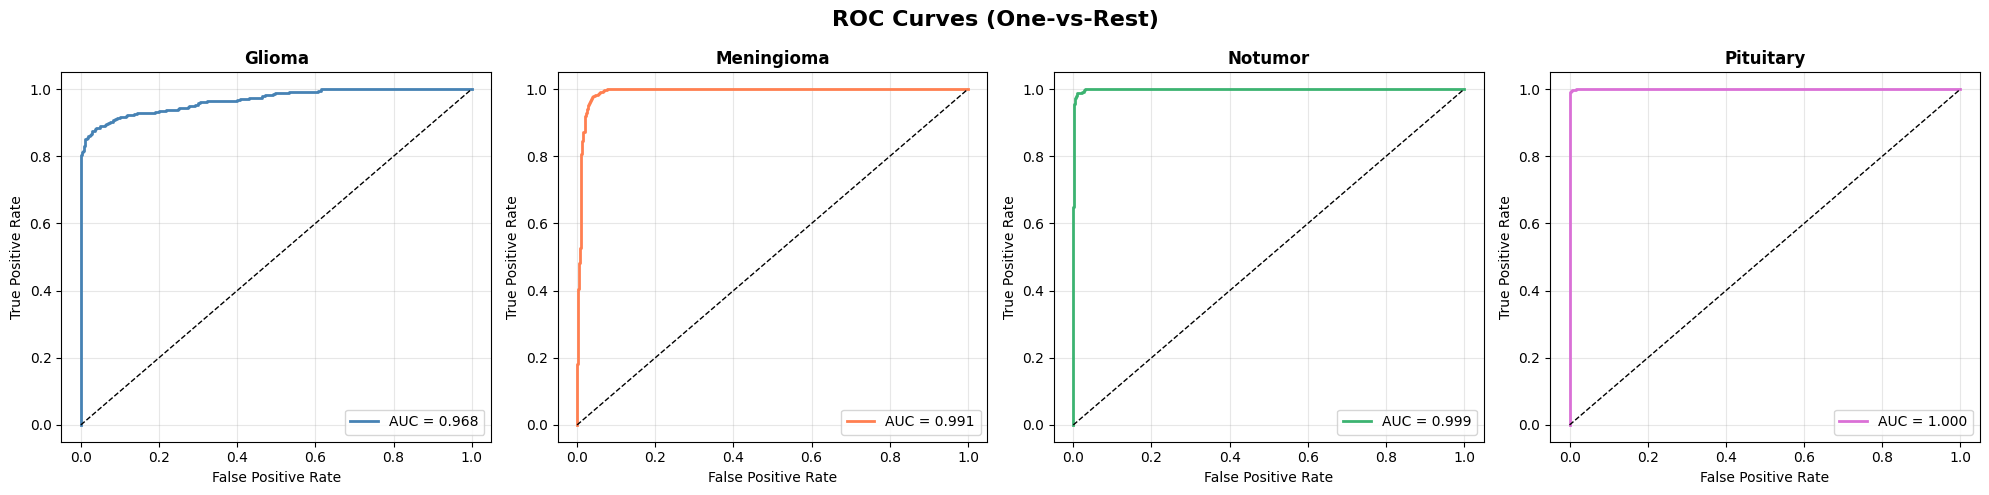

✅ Saved → results/roc_curves.png


In [ ]:
labels_bin = label_binarize(all_labels, classes=range(NUM_CLASSES))

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 5))
fig.suptitle('ROC Curves (One-vs-Rest)', fontsize=16, fontweight='bold')

colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid']

for i, (cls, color) in enumerate(zip(CLASSES, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    axes[i].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[i].set_title(cls.capitalize(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved → results/roc_curves.png')

## 7. Error Analysis — What Did the Model Get Wrong?

Looking at misclassified images helps us understand the model's failure modes.

Total misclassified: 89 / 1600 (5.56%)


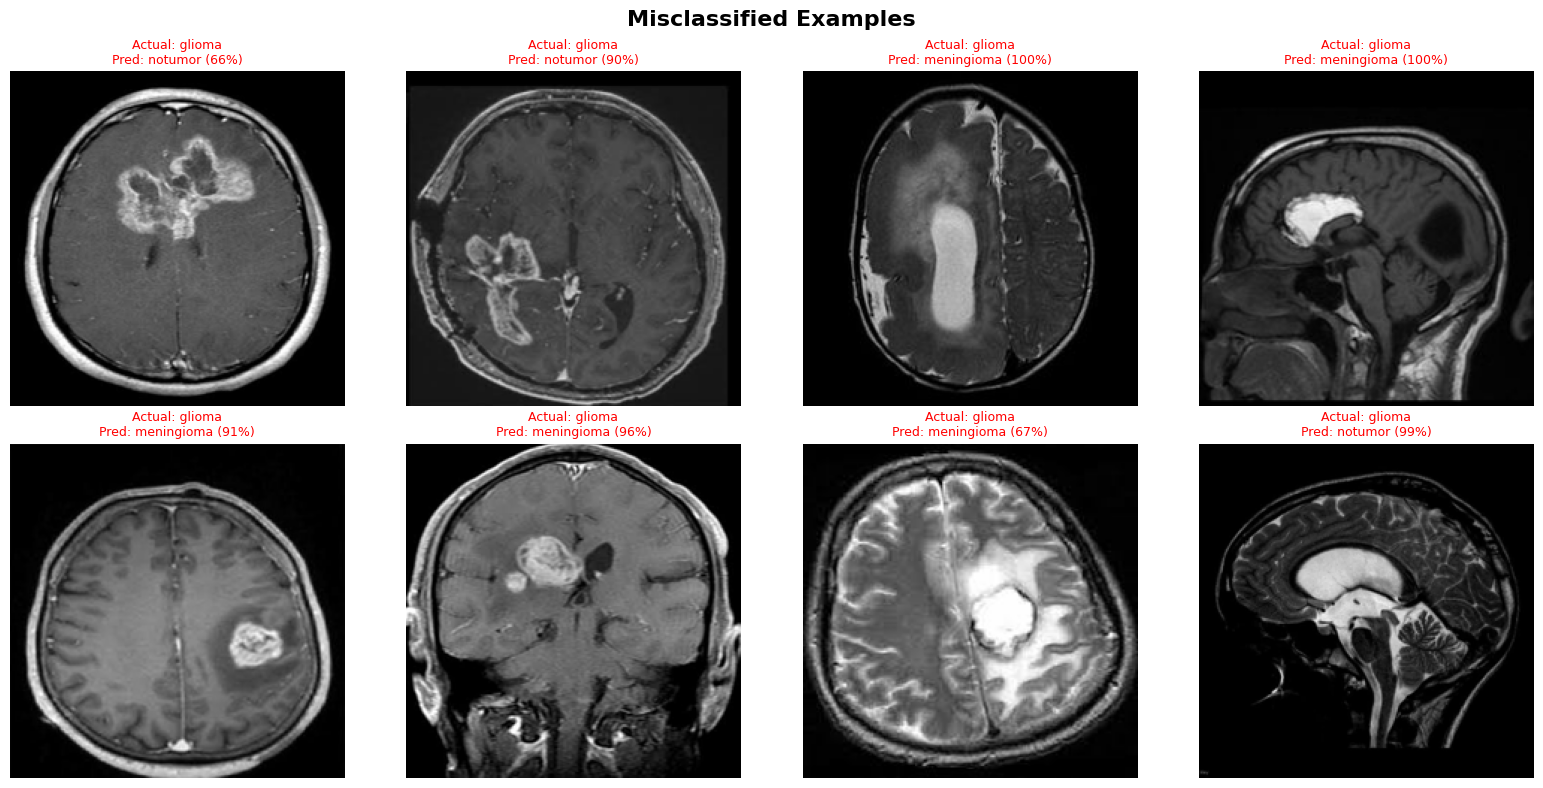

✅ Saved → results/misclassified.png


In [ ]:
# Find misclassified samples
wrong_indices = np.where(all_preds != all_labels)[0]
print(f'Total misclassified: {len(wrong_indices)} / {len(all_labels)} '
      f'({len(wrong_indices)/len(all_labels):.2%})')

# Show up to 8 misclassified images
show_n = min(8, len(wrong_indices))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Misclassified Examples', fontsize=16, fontweight='bold')
axes = axes.flatten()

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

for i in range(show_n):
    idx       = wrong_indices[i]
    img_path, _ = test_dataset.samples[idx]
    img       = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    
    actual    = CLASSES[all_labels[idx]]
    predicted = CLASSES[all_preds[idx]]
    conf      = all_probs[idx][all_preds[idx]]
    
    axes[i].imshow(img)
    axes[i].set_title(f'Actual: {actual}\nPred: {predicted} ({conf:.0%})',
                      fontsize=9, color='red')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'misclassified.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved → results/misclassified.png')

## 8. Confidence Distribution

A well-calibrated model should be highly confident on correct predictions and less confident when it's wrong.

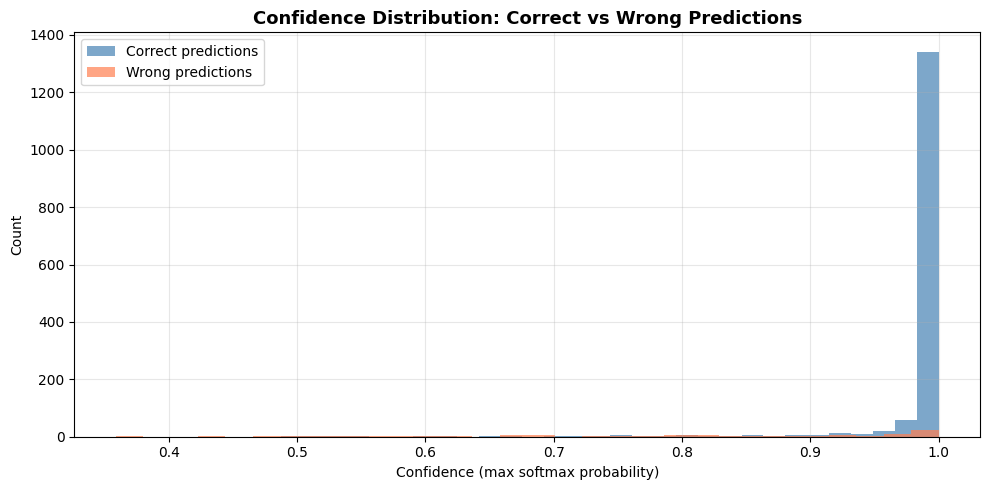

Avg confidence — Correct : 98.53%
Avg confidence — Wrong   : 83.29%


In [ ]:
correct_mask   = all_preds == all_labels
max_probs      = all_probs.max(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(max_probs[correct_mask],  bins=30, alpha=0.7,
        color='steelblue', label='Correct predictions')
ax.hist(max_probs[~correct_mask], bins=30, alpha=0.7,
        color='coral',     label='Wrong predictions')
ax.set_xlabel('Confidence (max softmax probability)')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution: Correct vs Wrong Predictions',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Avg confidence — Correct : {max_probs[correct_mask].mean():.2%}')
print(f'Avg confidence — Wrong   : {max_probs[~correct_mask].mean():.2%}')